In [129]:
import pandas as pd
import regex as re
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [130]:
df = pd.read_pickle("model_data.pkl")
df = df[df['multi_label'].notnull()]  # filter all hypothetical proteins out of the data frame

df['multi_label_clean'] = df['multi_label'].apply(
    lambda x: list(set([re.split('(.)\[|\(', s)[0].strip() for s in x.split(';')])))

unique_df = df[['KO', 'multi_label_clean']].drop_duplicates(['KO'])

In [131]:
functions_dict = {}
[functions_dict.update({func: (1 if func not in functions_dict else functions_dict[func] + 1)})
    for multi_lst in unique_df.multi_label_clean.tolist() for func in multi_lst]

functions_dict

{'Transcription factors': 633,
 'Arginine and proline metabolism': 101,
 'Pantothenate and CoA biosynthesis': 40,
 'Valine, leucine and isoleucine biosynthesis': 17,
 'Coronavirus disease - COVID-19': 125,
 'Ribosome': 160,
 'DNA repair and recombination proteins': 388,
 'Transporters': 1518,
 'Phenylalanine, tyrosine and tryptophan biosynthesis': 67,
 'Ribosome biogenesis': 313,
 'Alanine, aspartate and glutamate metabolism': 67,
 'Pyrimidine metabolism': 100,
 'Mismatch repair': 43,
 'Amino acid related enzymes': 100,
 'Enzymes with EC numbers': 1153,
 'Transfer RNA biogenesis': 239,
 'DNA replication proteins': 167,
 'Prokaryotic defense system': 164,
 'Cysteine and methionine metabolism': 112,
 'Chromosome and associated proteins': 773,
 'MicroRNAs in cancer': 63,
 'Methane metabolism': 187,
 'Streptomycin biosynthesis': 18,
 'Acarbose and validamycin biosynthesis': 24,
 'Polyketide sugar unit biosynthesis': 44,
 'Diabetic cardiomyopathy': 109,
 'Peptidases and inhibitors': 582,
 '

In [132]:
relevant_functions = [key for key, val in functions_dict.items() if val != 1]

# 516 relevant functions from 519 functions total

In [133]:
n = len(relevant_functions)

relevant_functions_dict = {relevant_functions[i]: i for i in range(n)}

func_mat = np.zeros((n, n))

for multi_lst in unique_df.multi_label_clean.tolist():
    if len(multi_lst) >= 2:
        for i in range(len(multi_lst)):
            for j in range(i+1, len(multi_lst)):
                try:
                    func_mat[relevant_functions_dict[multi_lst[i]], relevant_functions_dict[multi_lst[j]]] += 1
                    func_mat[relevant_functions_dict[multi_lst[j]], relevant_functions_dict[multi_lst[i]]] += 1
                except KeyError:
                    pass

In [134]:
func_mat # cell i,j has the numbr of uniqe KO's that has the functions i and j together (i.e. in the same multi_label)
# function i refers to relevant_functions[i]
# notice that the diagonal is zeros

array([[0., 1., 0., ..., 0., 2., 2.],
       [1., 0., 3., ..., 0., 0., 0.],
       [0., 3., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [2., 0., 0., ..., 0., 0., 0.],
       [2., 0., 0., ..., 0., 0., 0.]])

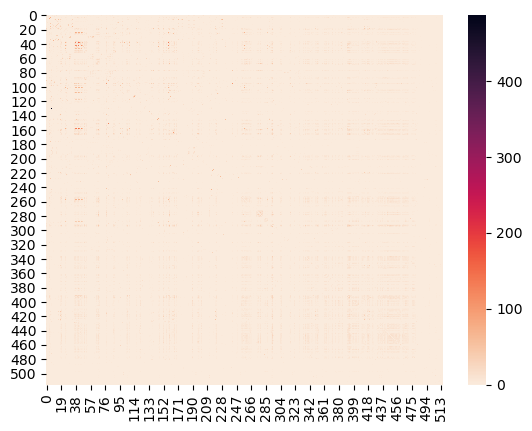

In [135]:
sns.heatmap(func_mat, cmap = "rocket_r")

plt.show()

# heatmap isn't very usefull, most values are 0

In [136]:
# func_mat contains mostly zeros due to the large number of functions (516)
mat_without_zeros = np.ma.masked_equal(func_mat, 0)

median = np.ma.median(mat_without_zeros) # finding the median value of func_mat ignoring zeros, 3.0
quan = np.quantile(func_mat, 0.99) # finding the 0.99 quantile including zeros, 13.0

# max value in func_mat - 487, for i, j = (7, 131), that means 'Transporters', 'ABC transporters'

In [137]:
pairs = set()

for i in range(n):
    for j in range(i+1, n):
        if func_mat[i][j] > median:
            pairs.add((relevant_functions[i], relevant_functions[j]))
            
# 923 pairs

In [138]:
pairs

{('Propanoate metabolism', 'beta-Alanine metabolism'),
 ('Bacterial invasion of epithelial cells',
  'Endocrine and other factor-regulated calcium reabsorption'),
 ('PI3K-Akt signaling pathway', 'Melanoma'),
 ('Osteoclast differentiation', 'Sphingolipid signaling pathway'),
 ('Pathways of neurodegeneration - multiple diseases', 'GnRH secretion'),
 ('Long-term depression', 'Serotonergic synapse'),
 ('Thyroid hormone signaling pathway', 'Choline metabolism in cancer'),
 ('Autophagy - animal', 'Non-small cell lung cancer'),
 ('Oocyte meiosis', 'Melanogenesis'),
 ('Shigellosis', 'Transcriptional misregulation in cancer'),
 ('Growth hormone synthesis, secretion and action',
  'Non-small cell lung cancer'),
 ('Renin secretion', 'Phototransduction - fly'),
 ('Neutrophil extracellular trap formation', 'Gastric acid secretion'),
 ('Amyotrophic lateral sclerosis', 'NOD-like receptor signaling pathway'),
 ('EGFR tyrosine kinase inhibitor resistance',
  'Thyroid hormone signaling pathway'),
 ('Dia

In [139]:
pairs = set()

for i in range(n):
    for j in range(i+1, n):
        if func_mat[i][j] > quan:
            pairs.add((relevant_functions[i], relevant_functions[j]))
            
# 243 pairs

In [140]:
pairs

{('Propanoate metabolism', 'beta-Alanine metabolism'),
 ('Neuroactive ligand-receptor interaction', 'Ion channels'),
 ('Alzheimer disease', 'Protein kinases'),
 ('Lipid and atherosclerosis', 'Focal adhesion'),
 ('Long-term depression', 'Serotonergic synapse'),
 ('Hepatitis C', 'Viral carcinogenesis'),
 ('Membrane trafficking', 'Lysosome'),
 ('Herpes simplex virus 1 infection', 'Human cytomegalovirus infection'),
 ('FoxO signaling pathway', 'PI3K-Akt signaling pathway'),
 ('DNA replication proteins', 'DNA replication'),
 ('Ion channels', 'Calcium signaling pathway'),
 ('Chromosome and associated proteins', 'Transcription machinery'),
 ('Vibrio cholerae infection', 'Rheumatoid arthritis'),
 ('Spinocerebellar ataxia', 'Proteasome'),
 ('Cytoskeleton proteins', 'Pathogenic Escherichia coli infection'),
 ('EGFR tyrosine kinase inhibitor resistance',
  'Human cytomegalovirus infection'),
 ('Amyotrophic lateral sclerosis', 'Oxidative phosphorylation'),
 ('Coronavirus disease - COVID-19',
  'Hu

In [141]:
# trying to create a more useful mat and heatmap
average_num_of_appearances = np.mean(np.array(list(functions_dict.values())))
relevant_functions_avg = [key for key, val in functions_dict.items() if val > average_num_of_appearances]

# number of relevant functions reduced to 132

In [142]:
average_num_of_appearances

64.96339113680155

In [143]:
n = len(relevant_functions_avg)

relevant_functions__avg_dict = {relevant_functions_avg[i]: i for i in range(n)}

func_mat_2 = np.zeros((n, n))

for multi_lst in unique_df.multi_label_clean.tolist():
    if len(multi_lst) >= 2:
        for i in range(len(multi_lst)):
            for j in range(i+1, len(multi_lst)):
                try:
                    func_mat_2[relevant_functions__avg_dict[multi_lst[i]], relevant_functions__avg_dict[multi_lst[j]]] += 1
                    func_mat_2[relevant_functions__avg_dict[multi_lst[j]], relevant_functions__avg_dict[multi_lst[i]]] += 1
                except KeyError:
                    pass

In [144]:
func_mat_2

array([[ 0.,  1.,  2., ...,  0.,  4.,  7.],
       [ 1.,  0.,  0., ...,  0.,  0.,  0.],
       [ 2.,  0.,  0., ...,  0., 12.,  1.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  6.,  0.],
       [ 4.,  0., 12., ...,  6.,  0.,  1.],
       [ 7.,  0.,  1., ...,  0.,  1.,  0.]])

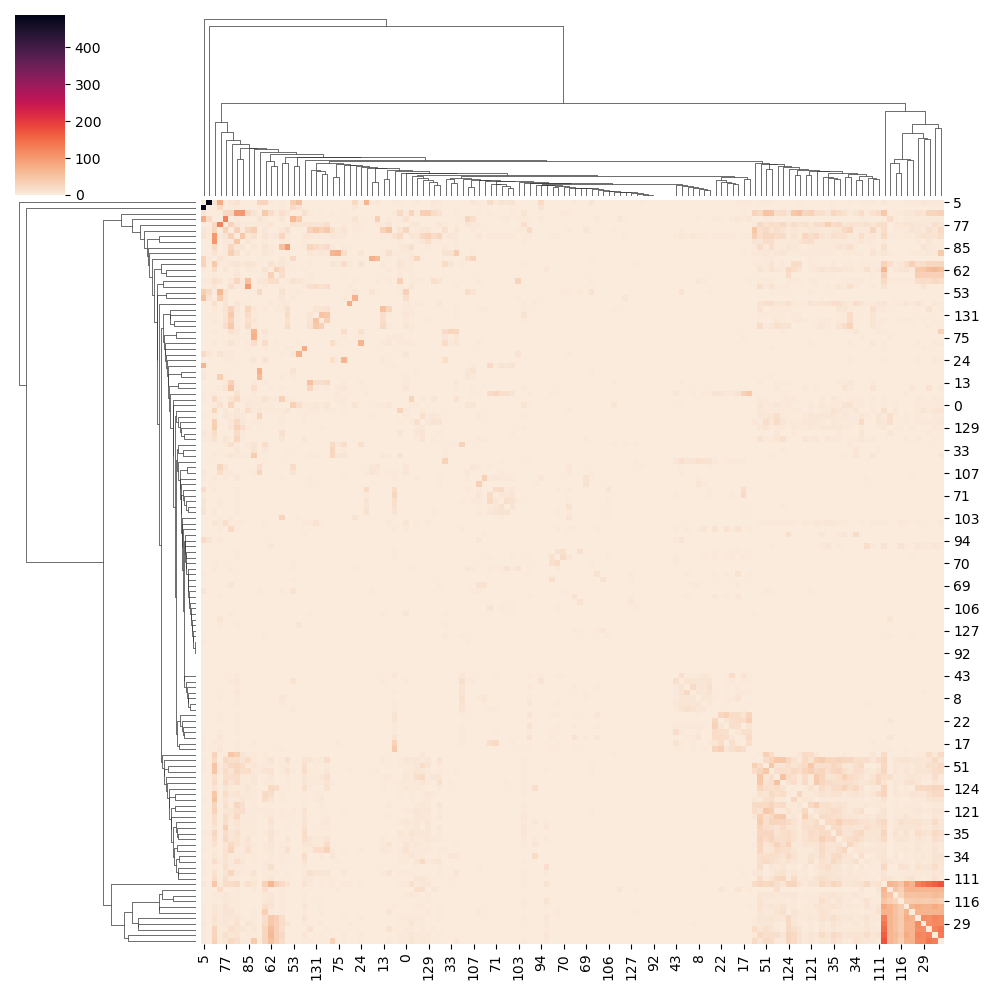

In [172]:
#sns.heatmap(func_mat_2, cmap = "rocket_r")
sns.clustermap(func_mat_2, cmap = "rocket_r")


plt.show()

Looking for exceptional KO values

In [121]:
df['multi_label_clean'].str.len().agg(['mean', 'max', 'median'])

mean        2.068611
max       123.000000
median      1.000000
Name: multi_label_clean, dtype: float64

C:\Users\shani\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


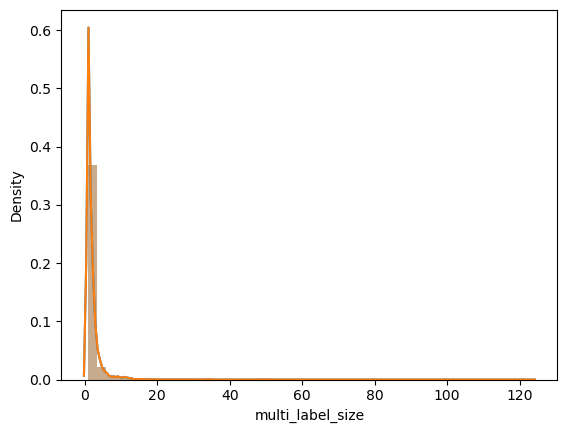

In [167]:
df['multi_label_size'] = df['multi_label_clean'].map(len)
sns.distplot(df['multi_label_size'])

plt.show()

In [122]:
df['exceptionaly_many_labels'] = df['multi_label_clean'].apply(lambda x: len(x) > 100)

In [123]:
df['exceptionaly_many_labels'].values.sum() 

5

In [124]:
df[df['exceptionaly_many_labels'] == True]["multi_label_clean"]

13690     [Melanoma, Chronic myeloid leukemia, Progester...
14266     [Melanoma, Chronic myeloid leukemia, Progester...
14484     [Melanoma, Chronic myeloid leukemia, Serotoner...
36786     [Melanoma, Chronic myeloid leukemia, Serotoner...
201936    [Melanoma, Chronic myeloid leukemia, Serotoner...
Name: multi_label_clean, dtype: object

In [125]:
optional_labels = df[df['exceptionaly_many_labels'] == True]["multi_label_clean"][13690]

In [155]:
df.loc[df['multi_label'].str.contains('Melanoma')]['multi_label_clean'].apply(len).mean()

50.21875

In [156]:
df.loc[df['multi_label'].str.contains('Chronic myeloid leukemia')]['multi_label_clean'].apply(len).mean()

50.30952380952381

average number of functions (labels) that come together with selected function (label):

In [157]:
for label in optional_labels:
    print(label + " : " + str(df.loc[df['multi_label'].str.contains(label)]['multi_label_clean'].apply(len).mean()))

Melanoma : 50.21875
Chronic myeloid leukemia : 50.30952380952381
Progesterone-mediated oocyte maturation : 26.47252747252747
Glioma : 49.223880597014926
Epstein-Barr virus infection : 20.101190476190474
Phosphatidylinositol signaling system : 14.430555555555555
TNF signaling pathway : 36.854166666666664
Acute myeloid leukemia : 63.57575757575758
Leukocyte transendothelial migration : 31.8125
Human papillomavirus infection : 19.428571428571427
VEGF signaling pathway : 51.073170731707314
Prolactin signaling pathway : 51.48717948717949
Endocrine resistance : 49.535714285714285
PI3K-Akt signaling pathway : 20.984189723320156
Longevity regulating pathway - worm : 13.097902097902098
Neurotrophin signaling pathway : 41.46511627906977
Viral carcinogenesis : 17.73404255319149
Coronavirus disease - COVID-19 : 9.596958174904943
Prostate cancer : 42.91304347826087
mTOR signaling pathway : 20.920529801324502
Non-small cell lung cancer : 44.11764705882353
Chagas disease : 39.32
Membrane trafficking 